In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np

# Load the classic MNIST dataset (handwritten digits)
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
train_images = train_images / 255.0
test_images = test_images / 255.0

print("✅ Data Loaded! Ready to build your AI.")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Data Loaded! Ready to build your AI.


In [4]:
# 1. Create a placeholder so other cells can "see" this variable
model = None

# Create Interactive Widgets
neuron_slider = widgets.IntSlider(value=64, min=8, max=256, step=8, description='Complexity:')
epoch_slider = widgets.IntSlider(value=3, min=1, max=10, description='Study Time:')
activation_dropdown = widgets.Dropdown(options=['relu', 'sigmoid', 'tanh'], value='relu', description='Logic Style:')
btn_train = widgets.Button(description="🚀 Train My AI", button_style='success')
output = widgets.Output()

def train_model(b):
    # 2. Tell the function to save the model to the global variable
    global model

    with output:
        clear_output()
        print(f"Training with {neuron_slider.value} neurons for {epoch_slider.value} rounds...")

        # Build model based on sliders
        model = models.Sequential([
            layers.Flatten(input_shape=(28, 28)),
            layers.Dense(neuron_slider.value, activation=activation_dropdown.value),
            layers.Dense(10, activation='softmax')
        ])

        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Train
        history = model.fit(train_images, train_labels, epochs=epoch_slider.value, validation_split=0.2, verbose=0)

        # Show Results
        acc = history.history['accuracy'][-1] * 100
        print(f"🏁 Training Finished! Your AI is {acc:.2f}% accurate.")

        # Test it on a random image
        idx = np.random.randint(0, len(test_images))
        img = test_images[idx]
        prediction = np.argmax(model.predict(img.reshape(1, 28, 28), verbose=0))

        plt.imshow(img, cmap='gray')
        plt.title(f"AI Guess: {prediction} | Real Digit: {test_labels[idx]}")
        plt.axis('off')
        plt.show()

btn_train.on_click(train_model)

# Display the "App"
ui = widgets.VBox([
    widgets.HTML("<b>Change parameters and hit Train:</b>"),
    neuron_slider, activation_dropdown, epoch_slider, btn_train
])
display(ui, output)

Output()

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create a button to generate the report
btn_report = widgets.Button(description="📊 Generate Report Card", button_style='info')
report_output = widgets.Output()

def show_confusion_matrix(b):
    with report_output:
        clear_output()

        # 1. Get predictions for the first 1000 test images
        # We use a subset so it's fast!
        test_subset = test_images[:1000]
        true_labels = test_labels[:1000]

        # Tell the model to guess
        predictions = model.predict(test_subset, verbose=0)
        predicted_labels = np.argmax(predictions, axis=1)

        # 2. Create the Matrix
        cm = confusion_matrix(true_labels, predicted_labels)

        # 3. Plot it beautifully
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=range(10), yticklabels=range(10))
        plt.xlabel('What the AI GUESSED')
        plt.ylabel('What the digit ACTUALLY was')
        plt.title('The Confusion Matrix: Identifying AI Mistakes')
        plt.show()

        print("💡 Pro-Tip: Look for numbers outside the diagonal line.")
        print("If you see a high number at Row 4, Column 9, your AI thinks 4s look like 9s!")

btn_report.on_click(show_confusion_matrix)
display(btn_report, report_output)

Button(button_style='info', description='📊 Generate Report Card', style=ButtonStyle())

Output()

In [10]:
btn_visualize = widgets.Button(description="👁️ See AI Features", button_style='warning')
vis_output = widgets.Output()

def visualize_weights(b):
    with vis_output:
        clear_output()
        if model is None:
            print("❌ Error: Train the AI first!")
            return

        # Get the weights of the first hidden layer
        # weights[0] is the matrix, weights[1] are the biases
        weights, biases = model.layers[1].get_weights()

        # We will show the first 10 neurons
        num_neurons = min(10, neuron_slider.value)
        plt.figure(figsize=(15, 3))

        for i in range(num_neurons):
            # Reshape the weights for one neuron back into a 28x28 square
            neuron_weights = weights[:, i].reshape(28, 28)

            plt.subplot(1, num_neurons, i + 1)
            # Use 'RdBu' (Red-Blue) map:
            # Red = "If there's a mark here, I think it's this number"
            # Blue = "If there's a mark here, it's definitely NOT this number"
            plt.imshow(neuron_weights, cmap='RdBu', vmin=-0.5, vmax=0.5)
            plt.title(f"Neuron {i+1}")
            plt.axis('off')

        plt.suptitle("What the Hidden Layer is looking for (Red = Positive, Blue = Negative)", fontsize=16)
        plt.show()
        print("💡 Each square is a 'filter'. Some look for top loops, others look for straight legs!")

btn_visualize.on_click(visualize_weights)
display(btn_visualize, vis_output)

Button(button_style='warning', description='👁️ See AI Features', style=ButtonStyle())

Output()

In [11]:
from IPython.display import HTML, Image
from google.colab import output as colab_output # Only if using Colab
import base64

canvas_html = """
<div style="border: 2px solid #444; padding: 20px; border-radius: 10px; background: #f9f9f9; width: 320px;">
    <p style="margin-top:0"><b>Draw a digit (0-9) here:</b></p>
    <canvas id="canvas" width="280" height="280" style="border: 1px solid #000; background: black; cursor: crosshair;"></canvas>
    <br>
    <button id="clear_btn" style="margin-top:10px; padding:8px; background:#ff4444; color:white; border:none; border-radius:4px; cursor:pointer;">🧹 Clear Canvas</button>
    <button id="predict_btn" style="margin-top:10px; padding:8px; background:#4CAF50; color:white; border:none; border-radius:4px; cursor:pointer;">🔍 Identify My Drawing</button>
</div>

<script>
    var canvas = document.getElementById('canvas');
    var ctx = canvas.getContext('2d');
    ctx.strokeStyle = 'white';
    ctx.lineWidth = 20;
    ctx.lineCap = 'round';
    var drawing = false;

    canvas.addEventListener('mousedown', () => { drawing = true; });
    canvas.addEventListener('mouseup', () => { drawing = false; ctx.beginPath(); });
    canvas.addEventListener('mousemove', draw);

    // Touch support for tablets/phones
    canvas.addEventListener('touchstart', (e) => { drawing = true; e.preventDefault(); });
    canvas.addEventListener('touchend', () => { drawing = false; ctx.beginPath(); });
    canvas.addEventListener('touchmove', (e) => {
        var touch = e.touches[0];
        var rect = canvas.getBoundingClientRect();
        draw({clientX: touch.clientX, clientY: touch.clientY});
    });

    function draw(e) {
        if (!drawing) return;
        var rect = canvas.getBoundingClientRect();
        ctx.lineTo(e.clientX - rect.left, e.clientY - rect.top);
        ctx.stroke();
        ctx.beginPath();
        ctx.moveTo(e.clientX - rect.left, e.clientY - rect.top);
    }

    document.getElementById('clear_btn').addEventListener('click', () => {
        ctx.clearRect(0, 0, canvas.width, canvas.height);
    });

    document.getElementById('predict_btn').addEventListener('click', () => {
        var dataURL = canvas.toDataURL('image/png');
        google.colab.kernel.invokeFunction('notebook.run_prediction', [dataURL], {});
    });
</script>
"""

def run_prediction(image_data):
    # Convert the drawing into a format the AI understands
    binary = base64.b64decode(image_data.split(',')[1])
    with open('drawing.png', 'wb') as f:
        f.write(binary)

    # Process image: Load, Resize to 28x28, Convert to Grayscale
    from PIL import Image as PILImage
    img = PILImage.open('drawing.png').convert('L').resize((28, 28))
    img_array = np.array(img) / 255.0

    # Predict!
    prediction = model.predict(img_array.reshape(1, 28, 28), verbose=0)
    digit = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    with output:
        clear_output(wait=True)
        print(f"🤖 AI says: 'I am {confidence:.1f}% sure that is a {digit}!''")
        plt.imshow(img_array, cmap='gray')
        plt.title(f"Processed Input (28x28)")
        plt.axis('off')
        plt.show()

# Connect the JavaScript to Python
try:
    from google.colab import output as colab_output
    colab_output.register_callback('notebook.run_prediction', run_prediction)
except ImportError:
    print("Running in local Jupyter? You'll need to use ipyevents for the canvas.")

display(HTML(canvas_html))
output = widgets.Output()
display(output)

Output()

## Letter example

In this second example, we will train an AI to regonize handwritten letters.

In [12]:
import tensorflow_datasets as tfds

# Load the EMNIST (Letters) dataset
ds, info = tfds.load('emnist/letters', with_info=True, as_supervised=True)
# Convert to numpy for easy manipulation
train_ds = tfds.as_numpy(ds['train'])

letters_images = []
letters_labels = []
for img, label in train_ds:
    letters_images.append(img.reshape(28, 28) / 255.0)
    letters_labels.append(label - 1) # EMNIST labels are 1-26

letters_images = np.array(letters_images)
letters_labels = np.array(letters_labels)

# Map numbers to actual alphabet
alphabet = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

print("✅ Letter Data Loaded!")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.6ECL3V_3.1.0/emnist-train.tfrecord*...:   0%|   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.6ECL3V_3.1.0/emnist-test.tfrecord*...:   0%|    …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.
✅ Letter Data Loaded!


In [13]:
# Create a 'Biased' training set: Only letters from the first 500 samples
# (Simulating a single person's handwriting style)
biased_images = letters_images[:500]
biased_labels = letters_labels[:500]

btn_train_letters = widgets.Button(description="✍️ Train on One Style", button_style='primary')
letter_output = widgets.Output()

def train_narrow_ai(b):
    global letter_model
    with letter_output:
        clear_output()
        print("Training AI on 'Person A's' handwriting style...")

        letter_model = models.Sequential([
            layers.Flatten(input_shape=(28, 28)),
            layers.Dense(128, activation='relu'),
            layers.Dense(26, activation='softmax')
        ])
        letter_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Train on the limited, biased set
        letter_model.fit(biased_images, biased_labels, epochs=10, verbose=0)
        print("🏁 Done! This AI thinks it's an expert on letters.")

btn_train_letters.on_click(train_narrow_ai)
display(btn_train_letters, letter_output)

Button(button_style='primary', description='✍️ Train on One Style', style=ButtonStyle())

Output()

In [14]:
btn_test_diff = widgets.Button(description="🎭 Test Different Styles", button_style='danger')
test_output = widgets.Output()

def test_on_strangers(b):
    with test_output:
        clear_output()
        # Pick a random letter from a completely different part of the dataset
        idx = np.random.randint(10000, 20000)
        test_img = letters_images[idx]
        actual_letter = alphabet[letters_labels[idx]]

        # Predict
        pred = letter_model.predict(test_img.reshape(1, 28, 28), verbose=0)
        guess = alphabet[np.argmax(pred)]

        plt.imshow(test_img.T, cmap='gray') # EMNIST is often rotated, .T flips it back
        plt.title(f"Actual Letter: {actual_letter} | AI Guess: {guess}")
        plt.axis('off')
        plt.show()

        if actual_letter == guess:
            print("Lucky guess! The styles were similar.")
        else:
            print(f"❌ FAIL: The AI couldn't recognize this '{actual_letter}' because it's not how 'Person A' writes it!")

btn_test_diff.on_click(test_on_strangers)
display(btn_test_diff, test_output)

Button(button_style='danger', description='🎭 Test Different Styles', style=ButtonStyle())

Output()

In [15]:
import matplotlib.pyplot as plt

def show_style_gap(letter_to_show='A'):
    # Convert letter to index (A=0, B=1, etc.)
    target_idx = alphabet.find(letter_to_show.upper())

    # 1. Find examples from the "Narrow/Biased" set
    biased_indices = np.where(biased_labels == target_idx)[0]

    # 2. Find examples from the "Diverse" set (the rest of the data)
    diverse_indices = np.where(letters_labels[500:] == target_idx)[0] + 500

    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(f"The Style Gap for the Letter '{letter_to_show}'", fontsize=16)

    # Row 0: What the AI learned (The "Biased" Person)
    for i in range(5):
        img = letters_images[biased_indices[i]].T # Transpose for correct orientation
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_title("Learned Style", loc='left', color='blue', fontweight='bold')

    # Row 1: What the AI is failing to recognize (The "Diverse" World)
    for i in range(5):
        img = letters_images[diverse_indices[i]].T
        axes[1, i].imshow(img, cmap='gray')
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_title("Real-World Styles", loc='left', color='red', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Create a dropdown for students to pick a letter
letter_picker = widgets.Dropdown(
    options=list(alphabet),
    value='A',
    description='Pick Letter:'
)

ui_gap = widgets.interactive(show_style_gap, letter_to_show=letter_picker)
display(ui_gap)

interactive(children=(Dropdown(description='Pick Letter:', options=('A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I…

In [16]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

btn_analytics = widgets.Button(description="📊 View Bias Report", button_style='info')
analytics_output = widgets.Output()

def show_bias_matrix(b):
    with analytics_output:
        clear_output()
        if 'letter_model' not in globals():
            print("❌ Please train the 'Narrow AI' first!")
            return

        # 1. Grab a diverse test set (letters from many different people)
        # We'll take a slice from the end of the dataset
        diverse_test_imgs = letters_images[-500:]
        diverse_test_labels = letters_labels[-500:]

        # 2. Get AI Predictions
        preds = letter_model.predict(diverse_test_imgs, verbose=0)
        pred_labels = np.argmax(preds, axis=1)

        # 3. Calculate the Matrix
        cm = confusion_matrix(diverse_test_labels, pred_labels, labels=range(26))

        # 4. Plot
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=False, cmap='Reds',
                    xticklabels=list(alphabet),
                    yticklabels=list(alphabet))
        plt.title("Confusion Matrix: Narrow AI vs. Diverse World", fontsize=16)
        plt.xlabel("What the AI 'Thought' it saw")
        plt.ylabel("What the letter 'Actually' was")
        plt.show()

        # Calculate general accuracy for the talk
        accuracy = np.trace(cm) / np.sum(cm) * 100
        print(f"📈 Generalization Accuracy: {accuracy:.1f}%")
        print("\n💡 OBSERVATION:")
        print("A 'General' AI would have a strong dark diagonal line.")
        print("Your 'Narrow' AI likely has dots everywhere—this is what happens when AI fails to generalize!")

btn_analytics.on_click(show_bias_matrix)
display(btn_analytics, analytics_output)

Button(button_style='info', description='📊 View Bias Report', style=ButtonStyle())

Output()

In [18]:
btn_compare = widgets.Button(description="📊 Compare Training vs. Reality", button_style='warning')
compare_output = widgets.Output()

def show_comparison_bars(b):
    with compare_output:
        clear_output()
        if 'letter_model' not in globals():
            print("❌ Please train the 'Narrow AI' first!")
            return

        # 1. Analyze Training Data (The Narrow Style)
        train_preds = np.argmax(letter_model.predict(biased_images, verbose=0), axis=1)
        train_pos = np.zeros(26)
        train_neg = np.zeros(26)
        for i in range(len(biased_labels)):
            if biased_labels[i] == train_preds[i]: train_pos[biased_labels[i]] += 1
            else: train_neg[biased_labels[i]] -= 1

        # 2. Analyze Test Data (The Diverse World)
        test_imgs = letters_images[-500:] # Last 500 images
        test_lbls = letters_labels[-500:]
        test_preds = np.argmax(letter_model.predict(test_imgs, verbose=0), axis=1)
        test_pos = np.zeros(26)
        test_neg = np.zeros(26)
        for i in range(len(test_lbls)):
            if test_lbls[i] == test_preds[i]: test_pos[test_lbls[i]] += 1
            else: test_neg[test_lbls[i]] -= 1

        # 3. Plotting Side-by-Side
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7), sharey=True)
        x = np.arange(26)

        # Chart 1: Training Data
        ax1.bar(x, train_pos, color='blue', label='Correct')
        ax1.bar(x, train_neg, color='red', label='Incorrect')
        ax1.axhline(0, color='black', linewidth=1)
        ax1.set_title("Performance on LEARNED Style (Training)", fontsize=14)
        ax1.set_xticks(x)
        ax1.set_xticklabels(list(alphabet))

        # Chart 2: Test Data
        ax2.bar(x, test_pos, color='blue', label='Correct')
        ax2.bar(x, test_neg, color='red', label='Incorrect')
        ax2.axhline(0, color='black', linewidth=1)
        ax2.set_title("Performance on NEW Styles (Test)", fontsize=14)
        ax2.set_xticks(x)
        ax2.set_xticklabels(list(alphabet))

        plt.suptitle("The Overfitting Gap: Memorization vs. Generalization", fontsize=18)
        plt.legend()
        plt.show()

        print("💡 THE REVEAL:")
        print("Left Chart: All blue? The AI has memorized this specific person's handwriting.")
        print("Right Chart: Lots of red? The AI is lost because it never learned that other styles exist.")

btn_compare.on_click(show_comparison_bars)
display(btn_compare, compare_output)

Button(button_style='warning', description='📊 Compare Training vs. Reality', style=ButtonStyle())

Output()

In [19]:
btn_filters = widgets.Button(description="👁️ Peek Inside the Brain", button_style='warning')
filter_output = widgets.Output()

def visualize_letter_filters(b):
    with filter_output:
        clear_output()
        if 'letter_model' not in globals():
            print("❌ Train the Narrow AI first!")
            return

        # Get weights from the first hidden layer
        weights, biases = letter_model.layers[1].get_weights()

        # Plot the first 10 neurons
        plt.figure(figsize=(15, 4))
        for i in range(10):
            # Reshape weights back to 28x28
            filter_pattern = weights[:, i].reshape(28, 28)

            plt.subplot(2, 5, i + 1)
            # Red/Blue map shows positive and negative importance
            plt.imshow(filter_pattern.T, cmap='RdBu', vmin=-0.2, vmax=0.2)
            plt.title(f"Neuron {i+1}")
            plt.axis('off')

        plt.suptitle("AI Feature Detectors: What the AI is 'hunting' for", fontsize=16)
        plt.show()
        print("💡 EXPLANATION:")
        print("- RED areas: If ink is here, the neuron says 'YES! This looks like my letter.'")
        print("- BLUE areas: If ink is here, the neuron says 'NO! This is definitely not it.'")

btn_filters.on_click(visualize_letter_filters)
display(btn_filters, filter_output)

Button(button_style='warning', description='👁️ Peek Inside the Brain', style=ButtonStyle())

Output()

In [20]:
btn_compare_brains = widgets.Button(description="🧠 Compare Brain Clarity", button_style='success')
brain_output = widgets.Output()

def compare_filters(b):
    with brain_output:
        clear_output()
        print("Training a 'Diverse Brain' on 10,000 images for comparison... (This takes 10 seconds)")

        # 1. Train a "Diverse" model on 10,000 samples
        diverse_model = models.Sequential([
            layers.Flatten(input_shape=(28, 28)),
            layers.Dense(128, activation='relu'),
            layers.Dense(26, activation='softmax')
        ])
        diverse_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        diverse_model.fit(letters_images[:10000], letters_labels[:10000], epochs=5, verbose=0)

        # 2. Get weights from both
        weights_narrow, _ = letter_model.layers[1].get_weights()
        weights_diverse, _ = diverse_model.layers[1].get_weights()

        # 3. Plot side-by-side
        fig, axes = plt.subplots(2, 5, figsize=(15, 7))

        for i in range(5):
            # Narrow filters (The messy ones)
            axes[0, i].imshow(weights_narrow[:, i].reshape(28, 28).T, cmap='RdBu', vmin=-0.1, vmax=0.1)
            axes[0, i].axis('off')
            if i == 2: axes[0, i].set_title("NARROW BRAIN (Messy/Overfit)\nNo clear patterns", fontweight='bold', color='red')

            # Diverse filters (The clean ones)
            axes[1, i].imshow(weights_diverse[:, i].reshape(28, 28).T, cmap='RdBu', vmin=-0.1, vmax=0.1)
            axes[1, i].axis('off')
            if i == 2: axes[1, i].set_title("DIVERSE BRAIN (Generalised)\nClear 'stencils' of letters appearing", fontweight='bold', color='green')

        plt.tight_layout()
        plt.show()
        print("💡 LOOK CLOSELY: Notice how the bottom row starts to look like actual brushstrokes?")

btn_compare_brains.on_click(compare_filters)
display(btn_compare_brains, brain_output)

Button(button_style='success', description='🧠 Compare Brain Clarity', style=ButtonStyle())

Output()

Training the Pro AI... watch how the 'Vision' improves.
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.4452 - loss: 2.0181
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6975 - loss: 0.9930
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7749 - loss: 0.7598


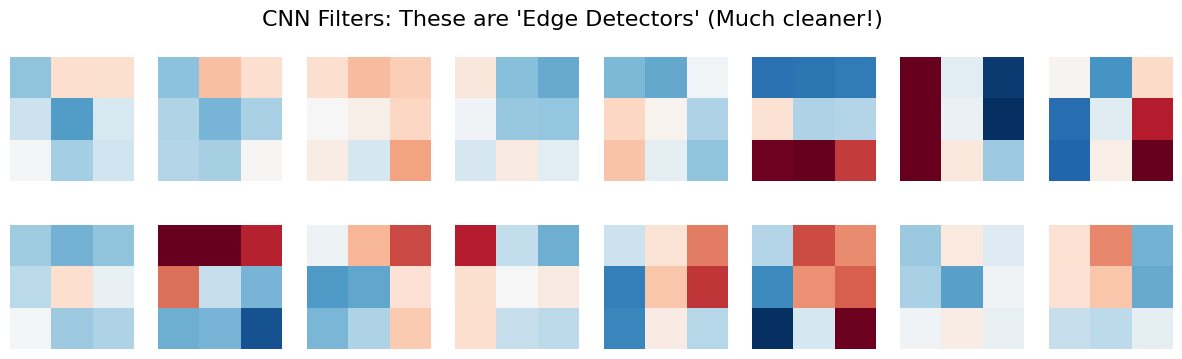

In [21]:
# Build a "Pro" Architecture (CNN)
pro_model = models.Sequential([
    layers.Reshape((28, 28, 1), input_shape=(28, 28)),
    layers.Conv2D(16, (3, 3), activation='relu'), # This is the "Magic" layer
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(26, activation='softmax')
])

pro_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train it on the diverse data
print("Training the Pro AI... watch how the 'Vision' improves.")
pro_model.fit(letters_images[:10000], letters_labels[:10000], epochs=3, verbose=1)

# Visualize the CNN Filters
weights = pro_model.layers[1].get_weights()[0] # Get the 16 filters

plt.figure(figsize=(15, 4))
for i in range(16):
    plt.subplot(2, 8, i + 1)
    # These are 3x3 filters zoomed in
    plt.imshow(weights[:, :, 0, i], cmap='RdBu', vmin=-0.5, vmax=0.5)
    plt.axis('off')
plt.suptitle("CNN Filters: These are 'Edge Detectors' (Much cleaner!)", fontsize=16)
plt.show()

In [27]:
import base64
from PIL import Image as PILImage
import io

# 1. THE BRAIN: The function that Python runs
def run_showdown(image_data):
    try:
        # 1. Decode & Resize
        binary = base64.b64decode(image_data.split(',')[1])
        img = PILImage.open(io.BytesIO(binary)).convert('L').resize((28, 28))
        img_array = np.array(img) / 255.0

        # 2. EMNIST Flip (Correction for the dataset's unique orientation)
        processed_img = img_array.T

        # 3. FIXING THE ERROR: Reshaping for each model
        # Narrow AI wants: [1 sample, 784 pixels]
        input_narrow = processed_img.reshape(1, 784)

        # Pro AI (CNN) wants: [1 sample, 28 pixels, 28 pixels, 1 color channel]
        # This is the "4D Tensor" it was complaining about!
        input_pro = processed_img.reshape(1, 28, 28, 1)

        # 4. Convert to TensorFlow Tensors (prevents the 'Unknown Rank' error)
        input_narrow = tf.convert_to_tensor(input_narrow, dtype=tf.float32)
        input_pro = tf.convert_to_tensor(input_pro, dtype=tf.float32)

        # 5. Predict
        pred_narrow = letter_model(input_narrow, training=False)
        pred_pro = pro_model(input_pro, training=False)

        res_narrow = alphabet[np.argmax(pred_narrow)]
        res_pro = alphabet[np.argmax(pred_pro)]
        conf_pro = np.max(pro_model.predict(input_pro, verbose=0)) * 100

        with showdown_output:
            clear_output(wait=True)
            print(f"✅ Connection Successful!")
            print(f"-------------------------------")
            print(f"Narrow AI Guess: {res_narrow}")
            print(f"Pro AI Guess:    {res_pro} ({conf_pro:.1f}% confident)")
            print(f"-------------------------------")

            plt.figure(figsize=(2,2))
            plt.imshow(processed_img, cmap='gray')
            plt.title("AI's Perspective:")
            plt.axis('off')
            plt.show()

    except Exception as e:
        with showdown_output:
            clear_output()
            print(f"⚠️ Debug Info: {e}")
            print("Tip: Re-run the Pro AI training cell to ensure the model exists!")

# 2. THE BRIDGE: Register the function for Colab
try:
    from google.colab import output as colab_output
    colab_output.register_callback('notebook.run_showdown', run_showdown)
except:
    print("Not in Colab? You may need to run this in a Google Colab environment for the JS bridge to work.")

# 3. THE FACE: The HTML/JS Drawing Pad
showdown_html = """
<div style="border: 2px solid #444; padding: 15px; text-align: center; width: 300px; background: #f0f0f0;">
    <canvas id="canvas" width="280" height="280" style="border: 1px solid #000; background: black;"></canvas>
    <button onclick="clearCanvas()" style="margin-top:10px;">Clear</button>
    <button onclick="sendToAI()" style="margin-top:10px; background: #4CAF50; color: white;">Compare AIs</button>
</div>
<script>
    var canvas = document.getElementById('canvas');
    var ctx = canvas.getContext('2d');
    ctx.strokeStyle = 'white'; ctx.lineWidth = 15; ctx.lineCap = 'round';
    var drawing = false;

    canvas.onmousedown = () => drawing = true;
    canvas.onmouseup = () => { drawing = false; ctx.beginPath(); };
    canvas.onmousemove = (e) => {
        if(!drawing) return;
        var rect = canvas.getBoundingClientRect();
        ctx.lineTo(e.clientX - rect.left, e.clientY - rect.top);
        ctx.stroke(); ctx.beginPath();
        ctx.moveTo(e.clientX - rect.left, e.clientY - rect.top);
    };

    function clearCanvas() { ctx.clearRect(0, 0, 280, 280); }

    function sendToAI() {
        var dataURL = canvas.toDataURL('image/png');
        google.colab.kernel.invokeFunction('notebook.run_showdown', [dataURL], {});
    }
</script>
"""

display(HTML(showdown_html))
showdown_output = widgets.Output()
display(showdown_output)

Output()